<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/Logistic_Regression%2BRandom_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 라이브러리 + 데이터 불러오기
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

FILE_PATH = "/content/drive/MyDrive/extention of Z-Alizadeh sani dataset.xlsx"

df = pd.read_excel(
    FILE_PATH,
    sheet_name="Sheet 1 - Table 1"
)

print(df.shape)
df.head()

(303, 59)


,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,...,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,LAD,LCX,RCA,Cath
0,53,90,175,Male,29.387755,0,1,1,0,0,...,39,52,261,50,0,N,Stenotic,Normal,Stenotic,CAD
1,67,70,157,Fmale,28.398718,0,1,0,0,0,...,38,55,165,40,4,N,Stenotic,Stenotic,Normal,CAD
2,54,54,164,Male,20.077335,0,0,1,0,0,...,38,60,230,40,2,mild,Stenotic,Normal,Normal,CAD
3,66,67,158,Fmale,26.838648,0,1,0,0,0,...,18,72,742,55,0,Severe,Normal,Normal,Normal,Normal
4,50,87,153,Fmale,37.165193,0,1,0,0,0,...,55,39,274,50,0,Severe,Normal,Normal,Normal,Normal


In [ ]:
# 데이터 기본 확인
print("전체 데이터:", df.shape)

print("\n결측치 개수:")
print(df.isnull().sum().sum())

print("\nCath 분포:")
print(df["Cath"].value_counts())

print("\nLAD:")
print(df["LAD"].value_counts())

print("\nLCX:")
print(df["LCX"].value_counts())

print("\nRCA:")
print(df["RCA"].value_counts())

전체 데이터: (303, 59)

결측치 개수:
0

Cath 분포:
Cath
CAD       216
Normal     87
Name: count, dtype: int64

LAD:
LAD
Stenotic    177
Normal      126
Name: count, dtype: int64

LCX:
LCX
Normal      184
Stenotic    119
Name: count, dtype: int64

RCA:
RCA
Normal      189
Stenotic    114
Name: count, dtype: int64


In [ ]:
# Target 설정
# Cath: CAD=1, Normal=0
y = df["Cath"].map({
    "CAD": 1,
    "Normal": 0
})

# 정상적으로 변환됐는지 확인
print("Target 분포:", y.value_counts())
print("\nTarget 결측치:", y.isnull().sum())

Target 분포: Cath
1    216
0     87
Name: count, dtype: int64

Target 결측치: 0


In [ ]:
# Leakage 및 불필요 변수 제거
X = df.drop(
    columns=[
        "Cath",         # Target
        "LAD",          # 조영술 결과 → Leakage
        "LCX",          # 조영술 결과 → Leakage
        "RCA",          # 조영술 결과 → Leakage
        "Exertional CP" # 전체 값 동일 → 상수 변수
    ]
).copy()

print("변수 제거 후 X shape:", X.shape)
print("y shape:", y.shape)

print("\n제거된 변수 확인:")
for column in ["Cath", "LAD", "LCX", "RCA", "Exertional CP"]:
  print(column, "→", column not in X.columns)

변수 제거 후 X shape: (303, 54)
y shape: (303,)

제거된 변수 확인:
Cath → True
LAD → True
LCX → True
RCA → True
Exertional CP → True


In [ ]:
# 문자열 범주형 변수 확인
categorical_columns = (
    X
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("문자열 범주형 변수:", categorical_columns)

for column in categorical_columns:
  print(f"\n[{column}]")
  print(X[column].value_counts(dropna=False))

문자열 범주형 변수: ['Sex', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Dyspnea', 'Atypical', 'Nonanginal', 'LowTH Ang', 'LVH', 'Poor R Progression', 'BBB', 'VHD']

[Sex]
Sex
Male     176
Fmale    127
Name: count, dtype: int64

[Obesity]
Obesity
Y    211
N     92
Name: count, dtype: int64

[CRF]
CRF
N    297
Y      6
Name: count, dtype: int64

[CVA]
CVA
N    298
Y      5
Name: count, dtype: int64

[Airway disease]
Airway disease
N    292
Y     11
Name: count, dtype: int64

[Thyroid Disease]
Thyroid Disease
N    296
Y      7
Name: count, dtype: int64

[CHF]
CHF
N    302
Y      1
Name: count, dtype: int64

[DLP]
DLP
N    191
Y    112
Name: count, dtype: int64

[Weak Peripheral Pulse]
Weak Peripheral Pulse
N    298
Y      5
Name: count, dtype: int64

[Lung rales]
Lung rales
N    292
Y     11
Name: count, dtype: int64

[Systolic Murmur]
Systolic Murmur
N    262
Y     41
Name: count, dtype

In [ ]:
# Sex Encoding
X["Sex"] = X["Sex"].map({
    "Male": 1,
    "Fmale": 0
})

print("Sex 변환 결과:", X["Sex"].value_counts(dropna=False))

# VHD Ordinal Encoding
# N=0 mild=1 Moderate=2 Severe=3
X["VHD"] = X["VHD"].map({
    "N": 0,
    "mild": 1,
    "Moderate": 2,
    "Severe": 3
})

print("\nVHD 변환 결과:", X["VHD"].value_counts(dropna=False).sort_index())

# Y/N 변수 encoding
# Y=1, N=0
yn_columns = []

for column in X.columns:
  # 문자열 변수만 검사
  if X[column].dtype == "object":
    unique_values = set(
        X[column].dropna().unique()
    )

    # Y/N으로만 구성된 변수
    if unique_values.issubset({"Y", "N"}):
      yn_columns.append(column)

print("\nY/N Encoding 대상:", yn_columns)

for column in yn_columns:
  X[column] = X[column].map({
      "Y": 1,
      "N": 0
  })

print("\nY/N Encoding 완료")

Sex 변환 결과: Sex
1    176
0    127
Name: count, dtype: int64

VHD 변환 결과: VHD
0    116
1    149
2     27
3     11
Name: count, dtype: int64

Y/N Encoding 대상: ['Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Dyspnea', 'Atypical', 'Nonanginal', 'LowTH Ang', 'LVH', 'Poor R Progression']

Y/N Encoding 완료


In [ ]:
# Encoding 후 문자열 변수 확인
remaining_categorical = (
    X
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("남아 있는 문자열 변수:", remaining_categorical)

for column in remaining_categorical:
  print(f"\n[{column}]")
  print(X[column].value_counts(dropna=False))

남아 있는 문자열 변수: ['BBB']

[BBB]
BBB
N       282
LBBB     13
RBBB      8
Name: count, dtype: int64


In [ ]:
# BBB One-Hot Encoding
X = pd.get_dummies(X, columns=["BBB"], prefix="BBB", dtype=int)

print("BBB One-Hot 후 X shape:", X.shape)

bbb_columns = [
    column
    for column in X.columns
    if column.startswith("BBB_")
]

print("\n생성된 BBB 변수:", bbb_columns)

BBB One-Hot 후 X shape: (303, 56)

생성된 BBB 변수: ['BBB_LBBB', 'BBB_N', 'BBB_RBBB']


In [ ]:
# 최종 전처리 결과 확인
print("최종 X shape", X.shape)
print("Target shape:", y.shape)
print("\nX 전체 결측치:", X.isnull().sum().sum())
print("y 결측치:", y.isnull().sum())
print("\n남아 있는 문자열 변수:", X.select_dtypes(exclude=np.number).columns.tolist())
print("\nTarget 분포:", y.value_counts())

최종 X shape (303, 56)
Target shape: (303,)

X 전체 결측치: 0
y 결측치: 0

남아 있는 문자열 변수: []

Target 분포: Cath
1    216
0     87
Name: count, dtype: int64


In [ ]:
# Development / Test 분리
RANDOM_STATE = 42

X_dev, X_test, y_dev, y_test = (train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=RANDOM_STATE
))

print("Development:", X_dev.shape)
print("Test:", X_test.shape)

print("\nDevelopment Target")
print(y_dev.value_counts())

print("\nTest Target")
print(y_test.value_counts())

Development: (272, 56)
Test: (31, 56)

Development Target
Cath
1    194
0     78
Name: count, dtype: int64

Test Target
Cath
1    22
0     9
Name: count, dtype: int64


In [ ]:
# Train / Validation 분리
# Development 내부 70% / 30%
X_train, X_val, y_train, y_val = (train_test_split(
    X_dev,
    y_dev,
    test_size=0.30,
    stratify=y_dev,
    random_state=RANDOM_STATE
))

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (190, 56)
Validation: (82, 56)
Test: (31, 56)


In [ ]:
# Weight-by-SVM
def weight_by_svm_ranking(X_train, y_train):

  # Scaling
  scaler = StandardScaler()

  X_scaled = scaler.fit_transform(X_train)

  # Linear SVM
  svm = LinearSVC(
      C=1.0,
      dual="auto",
      max_iter=20000,
      random_state=42
  )

  svm.fit(X_scaled, y_train)

  # Weight 추출
  weights = np.abs(svm.coef_.ravel())

  # 분산 0 변수는 중요도 0
  zero_variance = (np.std(X_scaled, axis=0) == 0)

  weights[zero_variance] = 0

  # Feature별 Score
  feature_scores = {
      feature: float(weight)

      for feature, weight
      in zip(X_train.columns, weights)
  }

  # Weight 큰 순서대로 정렬
  ranking = sorted(feature_scores, key=feature_scores.get, reverse=True)

  return(ranking, feature_scores)

In [ ]:
# Weight-by-SVM Feature Ranking
feature_ranking, feature_scores = (weight_by_svm_ranking(X_train, y_train))

print("Feature Ranking\n")

for rank, feature in enumerate(feature_ranking, start=1):
  print(rank, feature, feature_scores[feature])

Feature Ranking

1 Typical Chest Pain 1.2409199843481429
2 Neut 0.9741796748122882
3 BMI 0.9487461477512288
4 Lymph 0.8398516530081876
5 EF-TTE 0.6928620426412985
6 FH 0.6849680138424413
7 Tinversion 0.6843625514375022
8 DM 0.6604197707978814
9 St Elevation 0.6577400611708696
10 ESR 0.6484894089977904
11 TG 0.6132322661043793
12 LVH 0.5638493816732183
13 Lung rales 0.5562269612776397
14 Obesity 0.49531227270238004
15 VHD 0.4495746457903785
16 Weight 0.41901050605588797
17 HB 0.39118567333198495
18 Na 0.3748530805638544
19 Dyspnea 0.35226818956707034
20 Airway disease 0.30878876612751954
21 Sex 0.2876766199875672
22 Systolic Murmur 0.26802908130200176
23 HDL 0.26281437925785434
24 Weak Peripheral Pulse 0.26162070568018186
25 Function Class 0.2543308812075781
26 Region RWMA 0.25172055397229365
27 BBB_LBBB 0.2420427881567898
28 PR 0.2338268586703141
29 Thyroid Disease 0.23279754592038115
30 CRF 0.21431579832635697
31 Diastolic Murmur 0.2142334476215899
32 BP 0.1892018907267966
33 Q Wave 0

In [ ]:
# LR/RF Pipeline
def make_model_pipeline(X_reference, selected_features, model_name):

  # Logistic Regression
  if model_name == "LR":
    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                solver="liblinear",
                random_state=42
            )
        )
    ])

  # Random Forest
  elif model_name == "RF":
    pipeline = Pipeline([
          (
              "model",
              RandomForestClassifier(
                  n_estimators=500,
                  random_state=42,
                  n_jobs=-1
              )
          )
      ])

  else:
    raise ValueError("model_name은 LR 또는 RF")

  return pipeline

In [ ]:
# Validation 기반 Best K 탐색

# Best K 선택 기준
# 1. ROC-AUC 최대
# 2. 동일하면 더 작은 K
from sklearn.model_selection import StratifiedKFold

def find_best_k(model_name, feature_ranking, X_train, y_train, X_val, y_val):

  results = []

  # K = 1 ~ 전체 Feature 수
  for k in range(1, len(feature_ranking) + 1):

    # Top-K Feature 선택
    selected_features = (feature_ranking[:k])

    # 모델 생성
    model = make_model_pipeline(X_train, selected_features, model_name)

    # Train 학습
    model.fit(
        X_train[selected_features],
        y_train
    )

    # Validation 예측
    pred = model.predict(X_val[selected_features])
    prob = model.predict_proba(X_val[selected_features])[:, 1]

    # Confusion Matrix
    tn, fp, fn, tp = (confusion_matrix(y_val, pred, labels=[0, 1]).ravel())

    # 평가 지표
    accuracy = accuracy_score(y_val, pred)
    precision = precision_score(y_val, pred, zero_division=0)

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = f1_score(y_val, pred)
    auc = roc_auc_score(y_val, prob)

    # 현재 K 결과 저장
    results.append({
        "K": k,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": auc
    })

  # 결과 DataFrame
  results = pd.DataFrame(results)

  # Best K
  # ROC-AUC 최대
  # AUC 동일 → 작은 K
  best = (results.sort_values(
        by=["ROC-AUC", "K"],
        ascending=[False, True]).iloc[0]
  )

  best_k = int(best["K"])

  return best_k, results

In [ ]:
# Logistic Regression Validation 기반 K 탐색
best_k_lr, lr_validation_results = (
    find_best_k(
        model_name="LR",
        feature_ranking=feature_ranking,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val
    )
)

print("Logistic Regression Best K:", best_k_lr)

Logistic Regression Best K: 43


In [ ]:
# LR 상위 K 결과 확인
lr_top10 = (
    lr_validation_results

    .sort_values(
        by=["ROC-AUC", "K"],
        ascending=[False, True]
    ).head(10).reset_index(drop=True)
)

lr_top10

,K,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC
0,43,0.853659,0.925926,0.862069,0.833333,0.892857,0.938218
1,41,0.829268,0.907407,0.844828,0.791667,0.875000,0.935345
2,42,0.829268,0.907407,0.844828,0.791667,0.875000,0.935345
3,46,0.853659,0.925926,0.862069,0.833333,0.892857,0.934626
4,34,0.853659,0.910714,0.879310,0.791667,0.894737,0.933908
5,38,0.853659,0.910714,0.879310,0.791667,0.894737,0.933908
6,45,0.829268,0.907407,0.844828,0.791667,0.875000,0.933908
7,47,0.853659,0.925926,0.862069,0.833333,0.892857,0.933908
8,44,0.853659,0.925926,0.862069,0.833333,0.892857,0.933190
9,37,0.841463,0.909091,0.862069,0.791667,0.884956,0.932471


In [ ]:
# Random Forest Validation 기반 K 탐색
best_k_rf, rf_validation_results = (
    find_best_k(
        model_name="RF",
        feature_ranking=feature_ranking,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val
    )
)

print("Random Forest Best K:", best_k_rf)

Random Forest Best K: 46


In [ ]:
# RF 상위 결과 확인
rf_top10 = (
    rf_validation_results.sort_values(
        by=["ROC-AUC", "K"],
        ascending=[False, True]
    ).head(10).reset_index(drop=True)
)

rf_top10

,K,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC
0,46,0.878049,0.863636,0.982759,0.625000,0.919355,0.933190
1,39,0.890244,0.876923,0.982759,0.666667,0.926829,0.929598
2,38,0.890244,0.865672,1.000000,0.625000,0.928000,0.927802
3,49,0.878049,0.863636,0.982759,0.625000,0.919355,0.927802
4,34,0.853659,0.859375,0.948276,0.625000,0.901639,0.925287
5,42,0.878049,0.863636,0.982759,0.625000,0.919355,0.924569
6,52,0.878049,0.875000,0.965517,0.666667,0.918033,0.923851
7,43,0.890244,0.876923,0.982759,0.666667,0.926829,0.921695
8,36,0.829268,0.833333,0.948276,0.541667,0.887097,0.920977
9,41,0.890244,0.876923,0.982759,0.666667,0.926829,0.920259


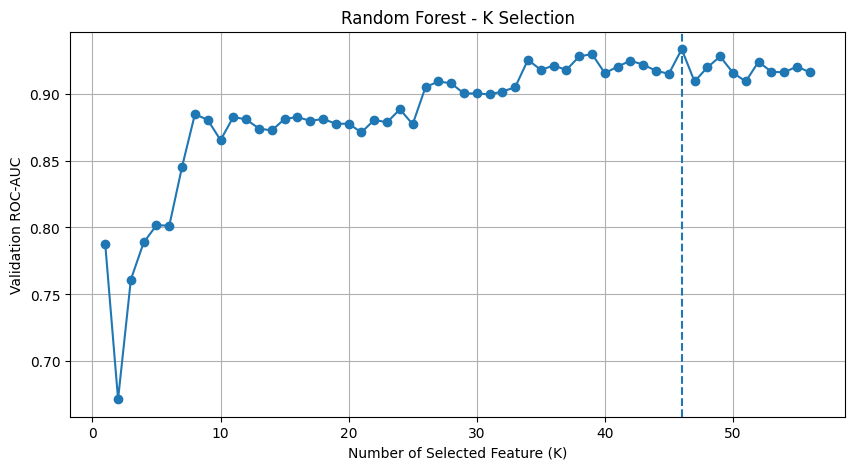

In [ ]:
# RF 그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    rf_validation_results["K"],
    rf_validation_results["ROC-AUC"],
    marker="o"
)

plt.axvline(x=best_k_rf, linestyle="--")

plt.xlabel("Number of Selected Feature (K)")
plt.ylabel("Validation ROC-AUC")
plt.title("Random Forest - K Selection")

plt.grid()

plt.show()

In [ ]:
# Best K 성능 비교
lr_best_result = (lr_validation_results[lr_validation_results["K"] == best_k_lr].copy())
lr_best_result["Model"] = ("Logistic Regression")

rf_best_result = (rf_validation_results[rf_validation_results["K"] == best_k_rf].copy())
rf_best_result["Model"] = ("Random Forest")

best_k_comparison = pd.concat([lr_best_result, rf_best_result], ignore_index=True)

best_k_comparison = (
    best_k_comparison[
        [
            "Model",
            "K",
            "Accuracy",
            "Precision",
            "Sensitivity",
            "Specificity",
            "F1-score",
            "ROC-AUC"
        ]
    ]
)

best_k_comparison

,Model,K,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC
0,Logistic Regression,43,0.853659,0.925926,0.862069,0.833333,0.892857,0.938218
1,Random Forest,46,0.878049,0.863636,0.982759,0.625000,0.919355,0.933190


In [ ]:
# Development 전체에서 Weight-by-SVM 재학습
final_ranking, final_feature_scores = (weight_by_svm_ranking(X_dev, y_dev))

# LR
selected_features_lr = (final_ranking[:best_k_lr])

# RF
selected_features_rf = (final_ranking[:best_k_rf])

# 확인
print("LR Best K:", best_k_lr)
print("LR Selected Features:", selected_features_lr)

print("\nRF Best K:", best_k_rf)
print("RF Selected Features:", selected_features_rf)

LR Best K: 43
LR Selected Features: ['BMI', 'Typical Chest Pain', 'Weight', 'TG', 'FH', 'EF-TTE', 'Length', 'Lymph', 'Sex', 'DM', 'VHD', 'Region RWMA', 'Dyspnea', 'Age', 'Neut', 'HB', 'St Elevation', 'LVH', 'Tinversion', 'Na', 'ESR', 'Obesity', 'PR', 'BP', 'Function Class', 'Edema', 'Lung rales', 'LDL', 'Weak Peripheral Pulse', 'HTN', 'Poor R Progression', 'BBB_LBBB', 'Systolic Murmur', 'St Depression', 'Airway disease', 'BBB_N', 'Atypical', 'K', 'Thyroid Disease', 'CRF', 'CHF', 'PLT', 'CVA']

RF Best K: 46
RF Selected Features: ['BMI', 'Typical Chest Pain', 'Weight', 'TG', 'FH', 'EF-TTE', 'Length', 'Lymph', 'Sex', 'DM', 'VHD', 'Region RWMA', 'Dyspnea', 'Age', 'Neut', 'HB', 'St Elevation', 'LVH', 'Tinversion', 'Na', 'ESR', 'Obesity', 'PR', 'BP', 'Function Class', 'Edema', 'Lung rales', 'LDL', 'Weak Peripheral Pulse', 'HTN', 'Poor R Progression', 'BBB_LBBB', 'Systolic Murmur', 'St Depression', 'Airway disease', 'BBB_N', 'Atypical', 'K', 'Thyroid Disease', 'CRF', 'CHF', 'PLT', 'CVA', 'Lo

In [ ]:
# Hyperparameter Tuning용 Feature
# Train 데이터에서 만든 Ranking 기준
tuning_features_lr = feature_ranking[:best_k_lr]
tuning_features_rf = feature_ranking[:best_k_rf]

print("LR Tuning Feature 수:", len(tuning_features_lr))
print("RF Tuning Feature 수:", len(tuning_features_rf))

print("\nLR Features:", tuning_features_lr)
print("\nRF Features:", tuning_features_rf)

LR Tuning Feature 수: 43
RF Tuning Feature 수: 46

LR Features: ['Typical Chest Pain', 'Neut', 'BMI', 'Lymph', 'EF-TTE', 'FH', 'Tinversion', 'DM', 'St Elevation', 'ESR', 'TG', 'LVH', 'Lung rales', 'Obesity', 'VHD', 'Weight', 'HB', 'Na', 'Dyspnea', 'Airway disease', 'Sex', 'Systolic Murmur', 'HDL', 'Weak Peripheral Pulse', 'Function Class', 'Region RWMA', 'BBB_LBBB', 'PR', 'Thyroid Disease', 'CRF', 'Diastolic Murmur', 'BP', 'Q Wave', 'Age', 'St Depression', 'DLP', 'BBB_RBBB', 'Poor R Progression', 'FBS', 'BBB_N', 'K', 'BUN', 'Current Smoker']

RF Features: ['Typical Chest Pain', 'Neut', 'BMI', 'Lymph', 'EF-TTE', 'FH', 'Tinversion', 'DM', 'St Elevation', 'ESR', 'TG', 'LVH', 'Lung rales', 'Obesity', 'VHD', 'Weight', 'HB', 'Na', 'Dyspnea', 'Airway disease', 'Sex', 'Systolic Murmur', 'HDL', 'Weak Peripheral Pulse', 'Function Class', 'Region RWMA', 'BBB_LBBB', 'PR', 'Thyroid Disease', 'CRF', 'Diastolic Murmur', 'BP', 'Q Wave', 'Age', 'St Depression', 'DLP', 'BBB_RBBB', 'Poor R Progression', 'F

In [ ]:
# Validation 평가 함수
def calculate_metrics(y_true, y_pred, y_prob):

  tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, zero_division=0)
  sensitivity = (tp / (tp + fn) if (tp + fn) > 0 else 0)
  specificity = (tn / (tn + fp) if (tn + fp) > 0 else 0)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_prob)

  return {
      "Accuracy": accuracy,
      "Precision": precision,
      "Sensitivity": sensitivity,
      "Specificity": specificity,
      "F1-score": f1,
      "ROC-AUC": auc
  }

In [ ]:
# Logistic Regression Hyperparameter Grid
from sklearn.model_selection import ParameterGrid

lr_param_grid = {
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"]
}

# Logistic Regression Train → Validation 평가
lr_tuning_results = []

for params in ParameterGrid(lr_param_grid):
  model = Pipeline([
      (
          "scaler",
          StandardScaler()
      ),
      (
          "model",
          LogisticRegression(
              C=params["C"],
              penalty=params["penalty"],
              class_weight=params["class_weight"],
              solver="liblinear",
              max_iter=5000,
              random_state=42
          )
      )
  ])

  # Train 학습
  model.fit(
      X_train[tuning_features_lr],
      y_train
  )

  # Validation 예측
  pred = model.predict(X_val[tuning_features_lr])
  prob = model.predict_proba(X_val[tuning_features_lr])[:, 1]

  metrics = calculate_metrics(y_val, pred, prob)

  lr_tuning_results.append({
      "C": params["C"],
      "penalty": params["penalty"],
      "class_weight": params["class_weight"],

      **metrics
  })

lr_tuning_results = pd.DataFrame(lr_tuning_results)

In [ ]:
# LR Best Hyperparameter
# 1. ROC-AUC
# 2. Sensitivity
# 3. Specificity
lr_tuning_top10 = (
    lr_tuning_results.sort_values(
        by=["ROC-AUC", "Sensitivity", "Specificity"],
        ascending=[False, False, False]
    )
).head(10).reset_index(drop=True)

lr_tuning_top10

,C,penalty,class_weight,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC
0,0.30,l2,balanced,0.829268,0.978261,0.775862,0.958333,0.865385,0.943966
1,0.10,l2,balanced,0.817073,0.977778,0.758621,0.958333,0.854369,0.940374
2,0.30,l2,None,0.853659,0.910714,0.879310,0.791667,0.894737,0.939655
3,1.00,l2,None,0.853659,0.925926,0.862069,0.833333,0.892857,0.938218
4,1.00,l2,balanced,0.817073,0.957447,0.775862,0.916667,0.857143,0.938218
5,0.10,l2,None,0.853659,0.925926,0.862069,0.833333,0.892857,0.937500
6,1.00,l1,balanced,0.817073,0.938776,0.793103,0.875000,0.859813,0.937500
7,1.00,l1,None,0.829268,0.907407,0.844828,0.791667,0.875000,0.933908
8,3.00,l1,balanced,0.829268,0.923077,0.827586,0.833333,0.872727,0.933908
9,0.03,l2,None,0.841463,0.941176,0.827586,0.875000,0.880734,0.932471


In [ ]:
# LR 최적 파라미터 저장
lr_best_row = lr_tuning_top10.iloc[0]

best_lr_params = {
    "C": lr_best_row["C"],
    "penalty": lr_best_row["penalty"],
    "class_weight": lr_best_row["class_weight"]
}

print("Best LR Parameters:", best_lr_params)

print("\nValidation ROC-AUC:", lr_best_row["ROC-AUC"])
print("Sensitivity:", lr_best_row["Sensitivity"])
print("Specificity:", lr_best_row["Specificity"])

Best LR Parameters: {'C': np.float64(0.3), 'penalty': 'l2', 'class_weight': 'balanced'}

Validation ROC-AUC: 0.9439655172413792
Sensitivity: 0.7758620689655172
Specificity: 0.9583333333333334


In [ ]:
# Random Forest Hyperparameter Randomized Search
from sklearn.model_selection import ParameterSampler

rf_param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

In [ ]:
# RF Randomized Tuning
rf_tuning_results = []

rf_parameter_samples = list(
    ParameterSampler(
        rf_param_grid,
        n_iter=60,
        random_state=42
    )
)

for params in rf_parameter_samples:
  model = RandomForestClassifier(
      n_estimators=params["n_estimators"],
      max_depth=params["max_depth"],
      min_samples_split=params["min_samples_split"],
      min_samples_leaf=params["min_samples_leaf"],
      max_features=params["max_features"],
      class_weight=params["class_weight"],
      random_state=42,
      n_jobs=-1
  )

  # Train 학습
  model.fit(
      X_train[tuning_features_rf],
      y_train
  )

  # Validation 예측
  pred = model.predict(X_val[tuning_features_rf])
  prob = model.predict_proba(X_val[tuning_features_rf])[:, 1]

  metrics = calculate_metrics(y_val, pred, prob)

  rf_tuning_results.append({
      **params,
      **metrics
  })

rf_tuning_results = pd.DataFrame(rf_tuning_results)

In [ ]:
# RF 상위 10개 결과 확인
rf_tuning_top10 = (
    rf_tuning_results.sort_values(
        by=["ROC-AUC", "Sensitivity", "Specificity"],
        ascending=[False, False, False]
    )
).head(10).reset_index(drop=True)

rf_tuning_top10

,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,class_weight,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC
0,300,10,1,0.3,3.0,balanced_subsample,0.841463,0.894737,0.879310,0.750000,0.886957,0.926724
1,300,10,2,sqrt,NaN,balanced,0.878049,0.887097,0.948276,0.708333,0.916667,0.926006
2,800,2,2,0.3,7.0,balanced_subsample,0.878049,0.875000,0.965517,0.666667,0.918033,0.923132
3,800,10,2,0.3,5.0,balanced_subsample,0.841463,0.881356,0.896552,0.708333,0.888889,0.922414
4,800,20,1,sqrt,3.0,None,0.768293,0.753247,1.000000,0.208333,0.859259,0.921695
5,800,2,2,sqrt,10.0,balanced,0.890244,0.888889,0.965517,0.708333,0.925620,0.921695
6,800,2,2,log2,5.0,balanced,0.890244,0.888889,0.965517,0.708333,0.925620,0.921695
7,500,10,4,log2,NaN,balanced,0.853659,0.883333,0.913793,0.708333,0.898305,0.920259
8,1000,10,2,0.3,10.0,balanced_subsample,0.841463,0.868852,0.913793,0.666667,0.890756,0.920259
9,500,2,1,0.3,10.0,None,0.878049,0.875000,0.965517,0.666667,0.918033,0.919540


In [ ]:
# RF Best Parameter 저장
rf_best_row = rf_tuning_top10.iloc[0]

best_rf_params = {
    "n_estimators": int(rf_best_row["n_estimators"]),
    "max_depth": rf_best_row["max_depth"],
    "min_samples_split": int(rf_best_row["min_samples_split"]),
    "min_samples_leaf": int(rf_best_row["min_samples_leaf"]),
    "max_features": rf_best_row["max_features"],
    "class_weight": rf_best_row["class_weight"]
}

print("Best RF Parameters:", best_rf_params)

print("\nValidation ROC-AUC:", rf_best_row["ROC-AUC"])
print("Sensitivity:", rf_best_row["Sensitivity"])
print("Specificity:", rf_best_row["Specificity"])

Best RF Parameters: {'n_estimators': 300, 'max_depth': np.float64(3.0), 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.3, 'class_weight': 'balanced_subsample'}

Validation ROC-AUC: 0.9267241379310345
Sensitivity: 0.8793103448275862
Specificity: 0.75


In [ ]:
# Development 전체에서 Weight-by-SVM 재학습
final_ranking, final_feature_scores = (weight_by_svm_ranking(X_dev, y_dev))

# LR 최종 Feature
selected_features_lr = (final_ranking[:best_k_lr])

# RF 최종 Feature
selected_features_rf = (final_ranking[:best_k_rf])

print("LR Best K:", best_k_lr)
print("LR Feature 수:", len(selected_features_lr))
print("\nRF Best K:", best_k_rf)
print("RF Feature 수:", len(selected_features_rf))

LR Best K: 43
LR Feature 수: 43

RF Best K: 46
RF Feature 수: 46


In [ ]:
# 최종 Logistic Regression 모델
final_lr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            C=float(best_lr_params["C"]),
            penalty=best_lr_params["penalty"],
            class_weight=best_lr_params["class_weight"],
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )
    )
])

# Development 전체 학습
final_lr.fit(
    X_dev[selected_features_lr],
    y_dev
)

print("Final Logistic Regression 학습 완료")

Final Logistic Regression 학습 완료


In [ ]:
# RF max_depth 자료형 정리
rf_max_depth = (
    None
    if pd.isna(best_rf_params["max_depth"])
    else int(best_rf_params["max_depth"])
)

# 최종 Random Forest 모델
final_rf = RandomForestClassifier(
    n_estimators=int(best_rf_params["n_estimators"]),
    max_depth=rf_max_depth,
    min_samples_split=int(best_rf_params["min_samples_split"]),
    min_samples_leaf=int(best_rf_params["min_samples_leaf"]),
    max_features=best_rf_params["max_features"],
    class_weight=best_rf_params["class_weight"],
    random_state=42,
    n_jobs=-1
)

# Development 전체 학습
final_rf.fit(
    X_dev[selected_features_rf],
    y_dev
)

print("Final Random Forest 학습 완료")

Final Random Forest 학습 완료


In [ ]:
# Test Prediction Probability
lr_test_prob = final_lr.predict_proba(X_test[selected_features_lr])[:, 1]
rf_test_prob = final_rf.predict_proba(X_test[selected_features_rf])[:, 1]

In [ ]:
# Test Prediction
# 기본 Threshold = 0.5
TEST_THRESHOLD = 0.5

lr_test_pred = (lr_test_prob >= TEST_THRESHOLD).astype(int)
rf_test_pred = (rf_test_prob >= TEST_THRESHOLD).astype(int)

In [ ]:
# 최종 Test 평가 함수
def evaluate_final_model(model_name, y_true, y_pred, y_prob):

  tn, fp, fn, tp = (confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel())

  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, zero_division=0)
  sensitivity = (tp / (tp + fn) if (tp + fn) > 0 else 0)
  specificity = (tn / (tn + fp) if (tn + fp) > 0 else 0)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_prob)

  return {
      "Model": model_name,
      "Accuracy": accuracy,
      "Precision": precision,
      "Sensitivity": sensitivity,
      "Specificity": specificity,
      "F1-score": f1,
      "ROC-AUC": auc,
      "TN": tn,
      "FP": fp,
      "FN": fn,
      "TP": tp
  }

In [ ]:
# Logistic Regression Test 평가
lr_test_result = (
    evaluate_final_model("Logistic Regression", y_test, lr_test_pred, lr_test_prob)
)

# Random Forest Test 평가
rf_test_result = (
    evaluate_final_model("Random Forest", y_test, rf_test_pred, rf_test_prob)
)

In [ ]:
# 최종 성능 비교
final_results = pd.DataFrame([lr_test_result, rf_test_result])

final_results

,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.838710,0.947368,0.818182,0.888889,0.878049,0.898990,8,1,4,18
1,Random Forest,0.870968,0.909091,0.909091,0.777778,0.909091,0.919192,7,2,2,20


In [ ]:
# 표시용 결과표
display_results = final_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC"
    ]
].copy()

numeric_columns = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC"
]

display_results[numeric_columns] = (display_results[numeric_columns].round(4))

display_results

,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,ROC-AUC
0,Logistic Regression,0.8387,0.9474,0.8182,0.8889,0.8780,0.8990
1,Random Forest,0.8710,0.9091,0.9091,0.7778,0.9091,0.9192


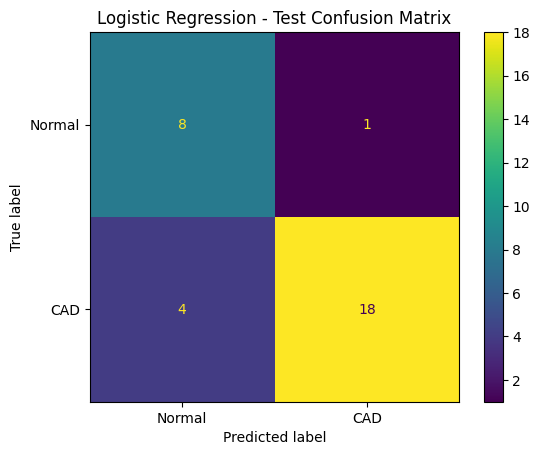

In [ ]:
# Confusion Matrix
from sklearn.metrics import (ConfusionMatrixDisplay)

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_test_pred,
    labels=[0, 1],
    display_labels=["Normal", "CAD"]
)

plt.title("Logistic Regression - Test Confusion Matrix")

plt.show()

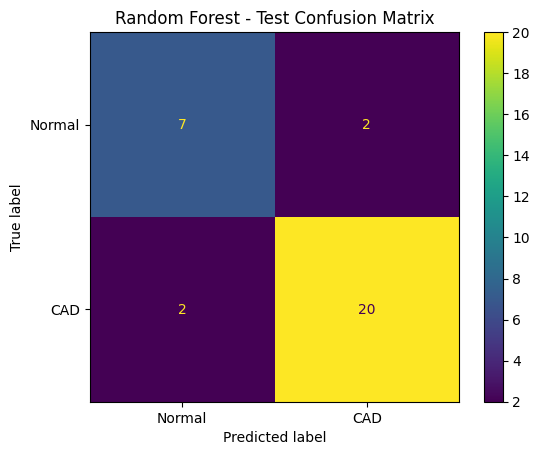

In [ ]:
# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_test_pred,
    labels=[0, 1],
    display_labels=["Normal", "CAD"]
)

plt.title("Random Forest - Test Confusion Matrix")

plt.show()

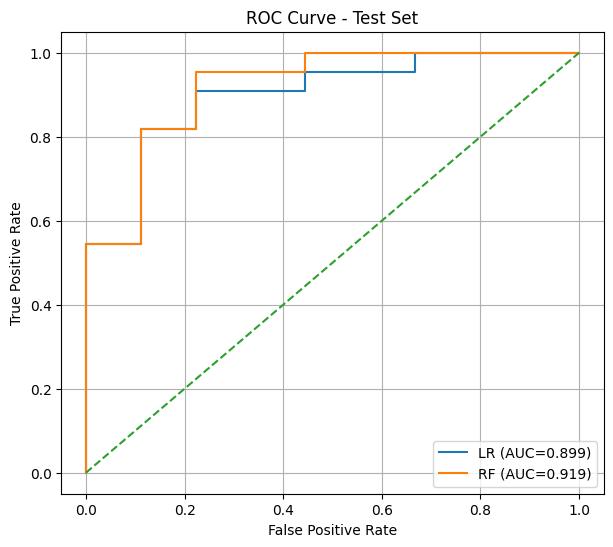

In [ ]:
# ROC Curve
from sklearn.metrics import (roc_curve)

# LR
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_test_prob)

# RF
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_prob)

plt.figure(figsize=(7, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=(
        f"LR "
        f"(AUC={lr_test_result['ROC-AUC']:.3f})"
    )
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=(
        f"RF "
        f"(AUC={rf_test_result['ROC-AUC']:.3f})"
    )
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Test Set")

plt.legend()
plt.grid()
plt.show()